# Explore here

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer # Paso 2: Usamos TF-IDF
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
import joblib

# Paso 1: Carga del conjunto de datos
url = "https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv"
df = pd.read_csv(url)

EDA: Análisis Exploratorio de Datos

In [6]:
# aquí verificarías duplicados y distribución antes de procesar
print(" Análisis Exploratorio de Datos")
print(f"Dimensiones del dataset: {df.shape}")
print(f"Valores nulos:\n{df.isnull().sum()}")
print(f"Balance de clases:\n{df['is_spam'].value_counts(normalize=True)}")



 Análisis Exploratorio de Datos
Dimensiones del dataset: (2999, 2)
Valores nulos:
url        0
is_spam    0
dtype: int64
Balance de clases:
is_spam
False    0.767923
True     0.232077
Name: proportion, dtype: float64


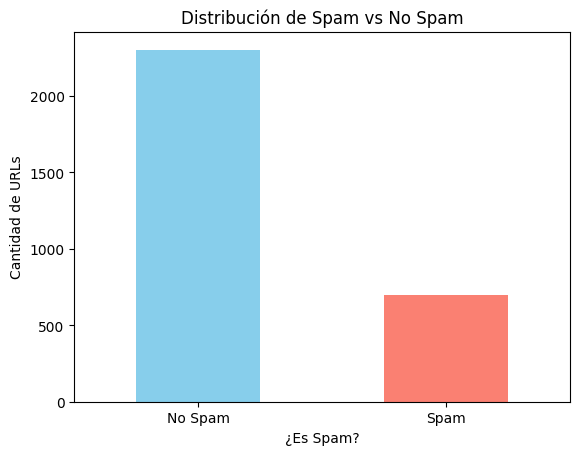

In [8]:
# Graficar el balance de clases
df['is_spam'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribución de Spam vs No Spam')
plt.xlabel('¿Es Spam?')
plt.ylabel('Cantidad de URLs')
plt.xticks([0, 1], ['No Spam', 'Spam'], rotation=0)
plt.show()

feature engineering

In [9]:
# Paso 2: Preprocesamiento (Feature Engineering)
# Creamos variables adicionales que ayudan a detectar patrones de spam
df['url_length'] = df['url'].apply(len)
df['count_dots'] = df['url'].apply(lambda x: x.count('.'))
df['has_https'] = df['url'].apply(lambda x: 1 if 'https' in x else 0)

Procesamiento y escalado 

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(token_pattern=r'(?u)\b\w\w+\b|[./:?&]')
X_text = vectorizer.fit_transform(df['url'])

# Extraemos las características numéricas
X_features = df[['url_length', 'count_dots', 'has_https']].values

# Escalado: Estandarizamos las características numéricas para que tengan media 0 y varianza 1
scaler = StandardScaler()
X_features_scaled = scaler.fit_transform(X_features)

# Combinamos con el texto
X = hstack([X_text, X_features_scaled])
y = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_text = vectorizer.fit_transform(df['url'])

# Extraemos las características numéricas
X_features = df[['url_length', 'count_dots', 'has_https']].values

# Escalado: Estandarizamos las características numéricas para que tengan media 0 y varianza 1
scaler = StandardScaler()
X_features_scaled = scaler.fit_transform(X_features)

# Combinamos con el texto
X = hstack([X_text, X_features_scaled])
y = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


NameError: name 'CountVectorizer' is not defined

Preprocesamiento de URLs

In [14]:
# Utilizamos CountVectorizer para transformar URLs en características numéricas
# El patrón de tokens captura caracteres alfanuméricos y signos de puntuación comunes en URLs
vectorizer = CountVectorizer(token_pattern=r'(?u)\b\w\w+\b|[./:?&]')
X = vectorizer.fit_transform(df['url'])
y = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


 Construcción de un SVM (Default)

In [15]:
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

print("Resultados SVM (Configuración Default):")
print(classification_report(y_test, svm_model.predict(X_test)))


Resultados SVM (Configuración Default):
              precision    recall  f1-score   support

       False       0.98      0.98      0.98       455
        True       0.93      0.93      0.93       145

    accuracy                           0.97       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.97      0.97      0.97       600



Optimización del modelo (GridSearch)

In [16]:
print("Iniciando optimización de hiperparámetros con GridSearch...")
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid = GridSearchCV(SVC(random_state=42), param_grid, cv=3, verbose=2)
grid.fit(X_train, y_train)

print(f"Mejor configuración encontrada: {grid.best_params_}")
best_svm = grid.best_estimator_

# Evaluación final con el modelo optimizado
print("\nResultados SVM (Optimizado):")
print(classification_report(y_test, best_svm.predict(X_test)))


Iniciando optimización de hiperparámetros con GridSearch...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ...............................C=0.1, kernel=linear; total time=   0.2s
[CV] END ...............................C=0.1, kernel=linear; total time=   0.2s
[CV] END ...............................C=0.1, kernel=linear; total time=   0.3s
[CV] END ..................................C=0.1, kernel=rbf; total time=   0.2s
[CV] END ..................................C=0.1, kernel=rbf; total time=   0.2s
[CV] END ..................................C=0.1, kernel=rbf; total time=   0.2s
[CV] END .................................C=1, kernel=linear; total time=   0.2s
[CV] END .................................C=1, kernel=linear; total time=   0.2s
[CV] END .................................C=1, kernel=linear; total time=   0.2s
[CV] END ....................................C=1, kernel=rbf; total time=   0.2s
[CV] END ....................................C=1, kernel=rbf; total ti

Guardado del modelo

In [17]:
joblib.dump(best_svm, 'svm_spam_detector.pkl')
print("\nModelo optimizado guardado exitosamente como 'svm_spam_detector.pkl'.")


Modelo optimizado guardado exitosamente como 'svm_spam_detector.pkl'.
